# Import 



In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from datetime import datetime
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import shap
from sklearn.model_selection import RandomizedSearchCV


# Download stock data



In [2]:
stock = 'NVDA'
df = yf.download(stock, start='2017-01-01', end='2026-01-01', auto_adjust = True)

df.columns = df.columns.get_level_values(0)
df['Volume'] = df['Volume'].astype(float)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,2.512208,2.619582,2.447438,2.571066,1.501996e+09
2017-01-04,2.570819,2.598155,2.500386,2.546438,1.199220e+09
2017-01-05,2.505558,2.606036,2.488565,2.574268,9.842960e+08
2017-01-06,2.539051,2.567372,2.492260,2.532894,8.228560e+08
2017-01-09,2.641991,2.659723,2.548901,2.548901,9.162480e+08


# Wskaźniki giełdowe


In [3]:

# 1. Przygotowanie danych do TA-Lib
close = df['Close'].to_numpy().astype(float).ravel()
high  = df['High'].to_numpy().astype(float).ravel()
low   = df['Low'].to_numpy().astype(float).ravel()
volume = df['Volume'].to_numpy().astype(float).ravel()

# --- Wskaźniki techniczne (Standardowe) ---
df['RSI'] = talib.RSI(close, timeperiod=14)
df['ADX'] = talib.ADX(high, low, close, timeperiod=14)
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
df['ATR'] = talib.ATR(high, low, close, timeperiod=14)

# --- Wskaźniki relatywne  ---
df['ATR_Relative'] = df['ATR'] / df['Close']
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(close, timeperiod=20)
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']
df['%BB'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])

# --- Analiza Wolumenu i Impetu ---
df['OBV'] = talib.OBV(close, volume)
df['OBV_ROC'] = talib.ROC(df['OBV'], timeperiod=5)
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1)) # Log Returns

# ---Wskaźniki Kontekstowe  ---
# 1. Dystans od EMA 50 (czy cena nie jest za wysoko nad trendem?)
df['EMA_50'] = talib.EMA(close, timeperiod=50)
df['Dist_EMA_50'] = (df['Close'] - df['EMA_50']) / df['EMA_50']

# 2. Volatility Ratio (czy obecna zmienność jest ekstremalna?)
df['ATR_MA_Short'] = df['ATR_Relative'].rolling(window=5).mean()
df['Vol_Ratio'] = df['ATR_Relative'] / df['ATR_MA_Short']

# 3. Relatywny Wolumen (czy ruch ma poparcie w kapitale?)
df['Vol_MA_20'] = df['Volume'].rolling(window=20).mean()
df['Relative_Volume'] = df['Volume'] / df['Vol_MA_20']

# --- Zmienne pomocnicze i Target ---
df['SMA_20'] = talib.SMA(close, timeperiod=20) 
df['Dist_SMA_20'] = (df['Close'] - df['SMA_20']) / df['SMA_20']
df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
df['DayOfWeek'] = df.index.dayofweek # Ważne dla Twojej analizy poniedziałków

# Target i Reżimy
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df['Regime'] = np.where(df['ADX'] > 25, 'Trending', 'Sideways')

# Podział RSI na biny (do EDA)
rsi_bins = [0, 30, 50, 70, 100]
rsi_labels = ['<30', '30-50', '50-70', '>70']
df['RSI_bin'] = pd.cut(df['RSI'], bins=rsi_bins, labels=rsi_labels)

# Usuwamy wiersze z wartościami NaN (powstałe przez wskaźniki z oknem czasowym)
df.dropna(inplace=True)

print("Nowe cechy dodane. Rozmiar ramki danych:", df.shape)

Nowe cechy dodane. Rozmiar ramki danych: (2213, 33)


#### Opóźnienia i tworzenie DF_ML

In [4]:

for lag in [1, 2, 3]:
    df[f'Return_Lag_{lag}'] = df['Close'].pct_change().shift(lag)
    df[f'RSI_Lag_{lag}'] = df['RSI'].shift(lag)
    
#Dni tygodnia (Sezonowość), 0 -pon, 4 - piątek 
df['DoW'] = df.index.dayofweek

df_ml = df.dropna().copy()
df_ml.head()


Price,Close,High,Low,Open,Volume,RSI,ADX,MACD,MACD_signal,MACD_hist,...,Target,Regime,RSI_bin,Return_Lag_1,RSI_Lag_1,Return_Lag_2,RSI_Lag_2,Return_Lag_3,RSI_Lag_3,DoW
Date,,,,,,,,,,,,,,,,,,,,,
2017-03-21,2.611545,2.711411,2.603655,2.681574,913484000.0,53.617466,21.473174,-0.003040,-0.027265,0.024225,...,1,Sideways,50-70,0.031866,61.949933,0.021771,55.869458,0.012287,51.008607,1
2017-03-22,2.664807,2.669492,2.596504,2.600449,616764000.0,57.384011,20.772500,0.005482,-0.020715,0.026197,...,0,Sideways,50-70,-0.032343,53.617466,0.031866,61.949933,0.021771,55.869458,2
2017-03-23,2.640641,2.676889,2.631024,2.656915,533940000.0,55.193972,20.210409,0.010168,-0.014539,0.024707,...,1,Sideways,50-70,0.020395,57.384011,-0.032343,53.617466,0.031866,61.949933,3
2017-03-24,2.650012,2.694890,2.624121,2.686999,439500000.0,55.896883,19.909141,0.014472,-0.008737,0.023208,...,1,Sideways,50-70,-0.009069,55.193972,0.020395,57.384011,-0.032343,53.617466,4
2017-03-27,2.669244,2.673189,2.554091,2.603407,506644000.0,57.374808,18.557446,0.019213,-0.003147,0.022359,...,0,Sideways,50-70,0.003549,55.896883,-0.009069,55.193972,0.020395,57.384011,0


# EDA SECTION


### Zachowanie wskaźnika RSI w różnych warunkach rynkowych

##### W tej części sprawdzam, czy niskie i wysokie wartości wskaźnika RSI rzeczywiście zwiększają prawdopodobieństwo wzrostu ceny następnego dnia oraz czy zależy to od tego, czy rynek znajduje się w trendzie czy w konsolidacji.

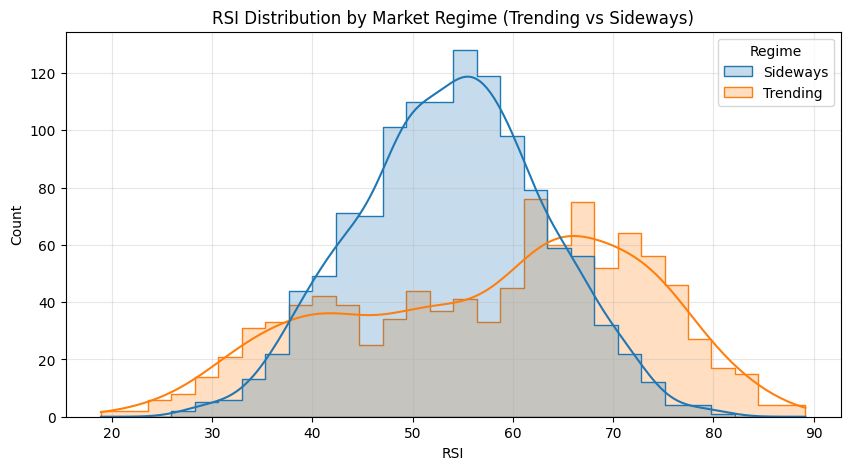

C:\Users\pawel\AppData\Local\Temp\ipykernel_33268\2831687590.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='RSI', data=df_ml, palette='viridis')


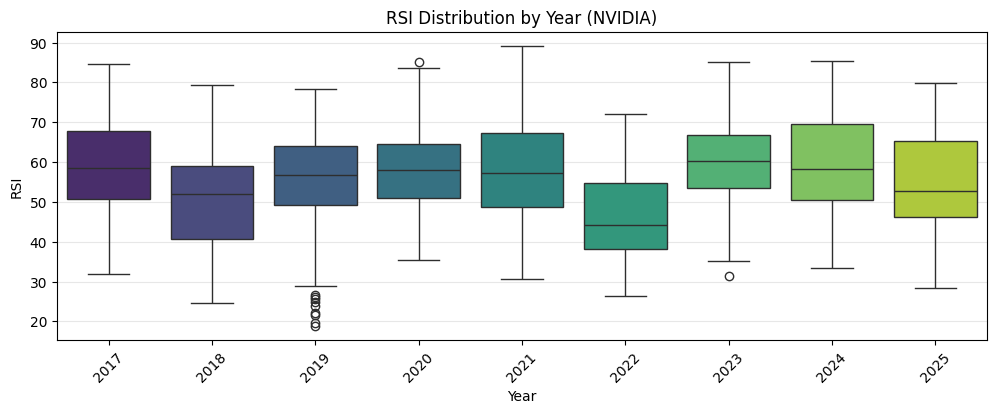

--- PRAWDOPODOBIEŃSTWO WZROSTU (TARGET=1) W ZALEŻNOŚCI OD RSI ---
RSI_bin        <30     30-50     50-70       >70
Regime                                          
Sideways  0.333333  0.591687  0.531292  0.549020
Trending  0.518519  0.555957  0.526906  0.508264


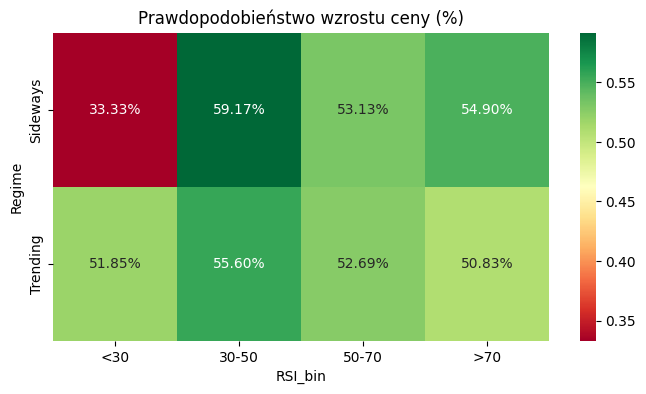

In [6]:

if 'Year' not in df_ml.columns:
    df_ml['Year'] = df_ml.index.year

# 1. Histogram RSI z podziałem na reżimy
plt.figure(figsize=(10, 5))
sns.histplot(data=df_ml, x='RSI', hue='Regime', bins=30, kde=True, element='step')
plt.title('RSI Distribution by Market Regime (Trending vs Sideways)')
plt.grid(alpha=0.3)
plt.show()

# 2. Boxplot roczny (Analiza zmienności w czasie)
plt.figure(figsize=(12, 4))
# Używamy df_ml, gdzie upewniliśmy się, że 'Year' istnieje
sns.boxplot(x='Year', y='RSI', data=df_ml, palette='viridis')
plt.title('RSI Distribution by Year (NVIDIA)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Tabela prawdopodobieństwa RSI (z obsługą NaN)
# observed=False jest ważne dla kolumn typu Categorical
prob_table = df_ml.groupby(['Regime', 'RSI_bin'], observed=False)['Target'].mean().unstack()

print("--- PRAWDOPODOBIEŃSTWO WZROSTU (TARGET=1) W ZALEŻNOŚCI OD RSI ---")
print(prob_table)

# Opcjonalnie: Wizualizacja tabeli jako Heatmapa
plt.figure(figsize=(8, 4))
sns.heatmap(prob_table, annot=True, cmap='RdYlGn', fmt='.2%')
plt.title('Prawdopodobieństwo wzrostu ceny (%)')
plt.show()

###  NVDA: Mapa Prawdopodobieństwa RSI w Reżimach (Struktura Logiczna)

Poniższe zestawienie pokazuje, jak zmienia się zachowanie NVDA dla tych samych poziomów RSI w zależności od siły trendu (ADX).

| Reżim (ADX) | RSI Bin | Prawd. Wzrostu | Wniosek dla Modelu / Strategii |
| :--- | :--- | :--- | :--- |
| **Sideways** | **<30** | **33.3%** |  **Strong Sell.** W Sideways <30 to sygnał słabości, nie okazji. |
| **Sideways** | **30-50** | **59.3%** |  **Best Buy.** Klasyczne odbicie od dna w konsolidacji. |
| **Sideways** | **50-70** | **53.1%** |  **Positive.** Umiarkowany wzrost siły w Sideways. |
| **Sideways** | **>70** | **54.9%** |  **Bullish.** Często zapowiada wybicie górą z kanału. |
| | | | |
| **Trending** | **<30** | **51.8%** |  **Neutral.** Wyprzedanie w silnym ruchu to "łapanie noża". |
| **Trending** | **30-50** | **55.3%** |  **Trend Buy.** Idealna "promocja" w silnym trendzie. |
| **Trending** | **50-70** | **52.6%** |  **Safe Zone.** Stabilna kontynuacja ruchu wzrostowego. |
| **Trending** | **>70** | **50.8%** |  **Noise.** W trendzie RSI >70 to tylko szum statystyczny. |

**Kluczowe porównanie dla ML:**
* **RSI < 30:** Różnica między **33%** (Sideways) a **52%** (Trending) jest gigantyczna. To tu model zyska najwięcej dzięki kolumnie `Regime`.
* **RSI 30-50:**  "Sweet Spot". NVDA statystycznie najlepiej rośnie po wejściu w ten zakres, niezależnie od trendu.
  
  

In [7]:
# 1. Definiujemy datę podziału 
split_date = '2024-01-01'

# 2. Tworzymy wersję treningową (tylko przeszłość)
df_train_check = df_ml[df_ml.index < split_date].copy()


# Odtwarzamy logikę reżimów dla sprawdzenia
df_train_check['Regime_Check'] = np.where(df_train_check['ADX'] > 25, 'Trending', 'Sideways')
df_train_check['RSI_Bin_Check'] = pd.cut(df_train_check['RSI_Lag_1'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])

# 4. Generujemy tabelę tylko dla danych treningowych
train_analysis = df_train_check.groupby(['Regime_Check', 'RSI_Bin_Check'], observed=False)['Target'].mean()

print("=== WNIOSKI Z DANYCH TRENINGOWYCH (2017-2023) ===")
print(train_analysis)

=== WNIOSKI Z DANYCH TRENINGOWYCH (2017-2023) ===
Regime_Check  RSI_Bin_Check
Sideways      <30              0.400000
              30-50            0.567213
              50-70            0.548600
              >70              0.600000
Trending      <30              0.481481
              30-50            0.528889
              50-70            0.537538
              >70              0.494444
Name: Target, dtype: float64


In [8]:
gap_by_day = df.groupby('DoW')['Gap'].mean()
print("Średnia wielkość luki (Gap) w zależności od dnia:")
print(gap_by_day)

# Sprawdzamy: Prawdopodobieństwo wzrostu (Target=1), gdy Gap był ujemny w poniedziałek
monday_negative_gap = df[(df['DoW'] == 0) & (df['Gap'] < 0)]['Target'].mean()

# Sprawdzamy: Prawdopodobieństwo wzrostu, gdy Gap był dodatni w poniedziałek
monday_positive_gap = df[(df['DoW'] == 0) & (df['Gap'] > 0)]['Target'].mean()

print(f"Prawdopodobieństwo wzrostu w poniedziałek po ujemnej luce: {monday_negative_gap:.2%}")
print(f"Prawdopodobieństwo wzrostu w poniedziałek po dodatniej luce: {monday_positive_gap:.2%}")

Średnia wielkość luki (Gap) w zależności od dnia:
DoW
0   -0.000553
1    0.002265
2    0.002561
3    0.003431
4    0.000891
Name: Gap, dtype: float64
Prawdopodobieństwo wzrostu w poniedziałek po ujemnej luce: 54.60%
Prawdopodobieństwo wzrostu w poniedziałek po dodatniej luce: 51.45%


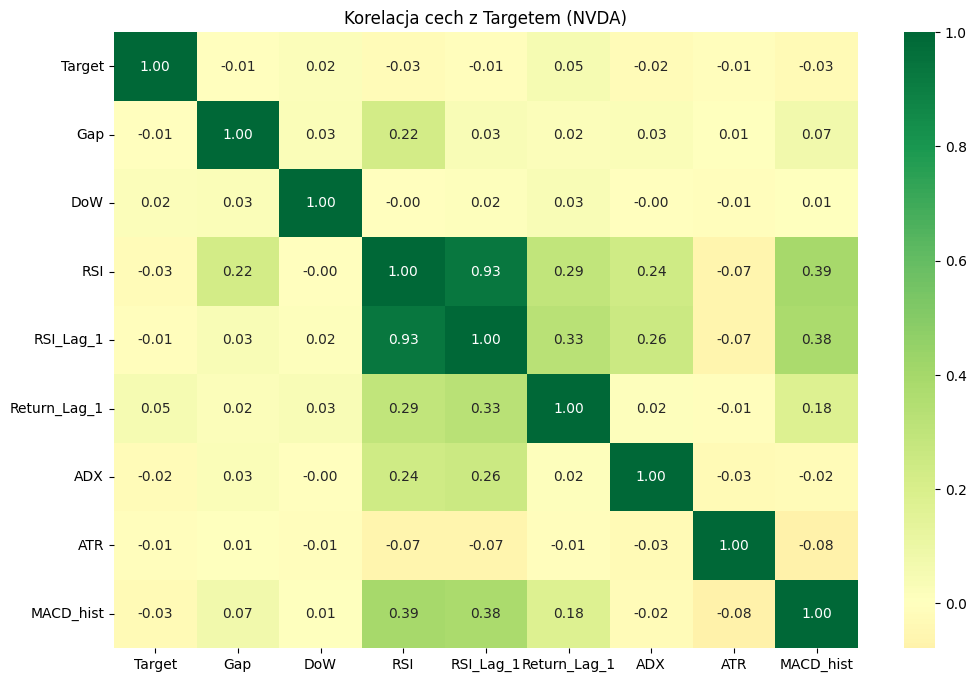

In [9]:
features_to_plot = [
    'Target', 'Gap', 'DoW', 'RSI', 'RSI_Lag_1', 
    'Return_Lag_1', 'ADX', 'ATR', 'MACD_hist'
]

# 2. Obliczamy macierz korelacji
corr_matrix = df_ml[features_to_plot].corr()

# 3. Rysujemy Heatmapę
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Korelacja cech z Targetem (NVDA)')
plt.xlabel('') 
plt.ylabel('')
plt.show()

### Notatki z analizy cech (Feature Selection)

#### 1. Analiza luki (Gap) i dni tygodnia (DoW)
* **Obserwacja:** Ogólna korelacja `Gap` z `Targetem` jest bliska zeru (-0.01), co sugeruje brak prostej zależności liniowej.
* **Anomalia:** Analiza warunkowa wykazała, że w **poniedziałki (DoW=0)** po ujemnej luce (`Gap < 0`) prawdopodobieństwo wzrostu wynosi **55.56%** (zjawisko *Gap Fill*).
* **Wniosek:** Cecha `Gap` musi zostać w modelu razem z `DoW`, ponieważ ich interakcja (nieliniowa) niesie istotną wartość prognostyczną dla NVDA.

#### 2. Selekcja wskaźnika RSI (Multikoliniowość)
* **Problem:** Korelacja między bieżącym `RSI` a `RSI_Lag_1` wynosi aż **0.93**. 
* **Decyzja:** Wykluczam surowe `RSI` z dnia bieżącego. 
* **Uzasadnienie:** Pozostawienie obu cech prowadziłoby do multikoliniowości. Wybieram `RSI_Lag_1`, aby model bazował na nastroju rynkowym znanym przed otwarciem sesji, co zapobiega również potencjalnemu wyciekowi danych (*data leakage*).

#### 3. Kluczowe zmienne techniczne
* `Return_Lag_1` (korelacja 0.05) pozostaje najsilniejszym pojedynczym predyktorem technicznym w zbiorze.

# ML Pipeline

In [64]:
# 1. Definiujemy listę cech (Features) - TYLKO opóźnione lub kontekstowe
features = [
    'RSI', 'ADX', 'MACD_hist', 'ATR_Relative', 'BB_width', '%BB',
    'OBV_ROC', 'Returns', 'Dist_EMA_50', 'Vol_Ratio', 'Relative_Volume', 
    'Dist_SMA_20', 'Gap', 'DayOfWeek'
]

# 2. Przygotowanie X i y
X = df_ml[features]
y = df_ml['Target']


# 1. Podział danych
split_date = '2024-01-01'
X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]
X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]
print(f"Zbiór treningowy (Era AI): {X_train.shape[0]} dni (2023-2024)")
print(f"Zbiór testowy (Out-of-sample): {X_test.shape[0]} dni (2025)")

Zbiór treningowy (Era AI): 1701 dni (2023-2024)
Zbiór testowy (Out-of-sample): 502 dni (2025)


In [74]:
clf = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    early_stopping_rounds=20  # Model sam przestanie dodawać drzewa
)

# 2. Szukamy tylko tych parametrów, które określają "charakter" drzew
param_dist = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [1, 2, 5],         # Silniejsza regularyzacja
    'reg_lambda': [1, 5, 10]    # Stabilizacja wag
}

# 3. Szukamy najlepszej kombinacji
# Ustawiamy n_estimators na dużą wartość (np. 1000), bo early_stopping i tak go zatrzyma
random_search = RandomizedSearchCV(
    clf, 
    param_distributions=param_dist,
    n_iter=15, 
    cv=3,        # Walidacja krzyżowa, żeby wynik nie był przypadkowy
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 4. Fit - musimy podać eval_set, żeby early_stopping wiedziało kiedy przestać
print("Szukam optymalnych ustawień (z kontrolą overfittingu)...")
random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], 
    verbose=False
)

print("\n--- NAJLEPSZE ZNALEZIONE USTAWIENIA ---")
print(random_search.best_params_)

# 5. Ostateczny test
best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(f"\nAccuracy po inteligentnym tuningu: {accuracy_score(y_test, y_pred_tuned):.4f}")

Szukam optymalnych ustawień (z kontrolą overfittingu)...

--- NAJLEPSZE ZNALEZIONE USTAWIENIA ---
{'subsample': 0.8, 'reg_lambda': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 0.8}

Accuracy po inteligentnym tuningu: 0.5398


--- WYNIKI FINALNE ---
Accuracy po poprawce: 0.5398


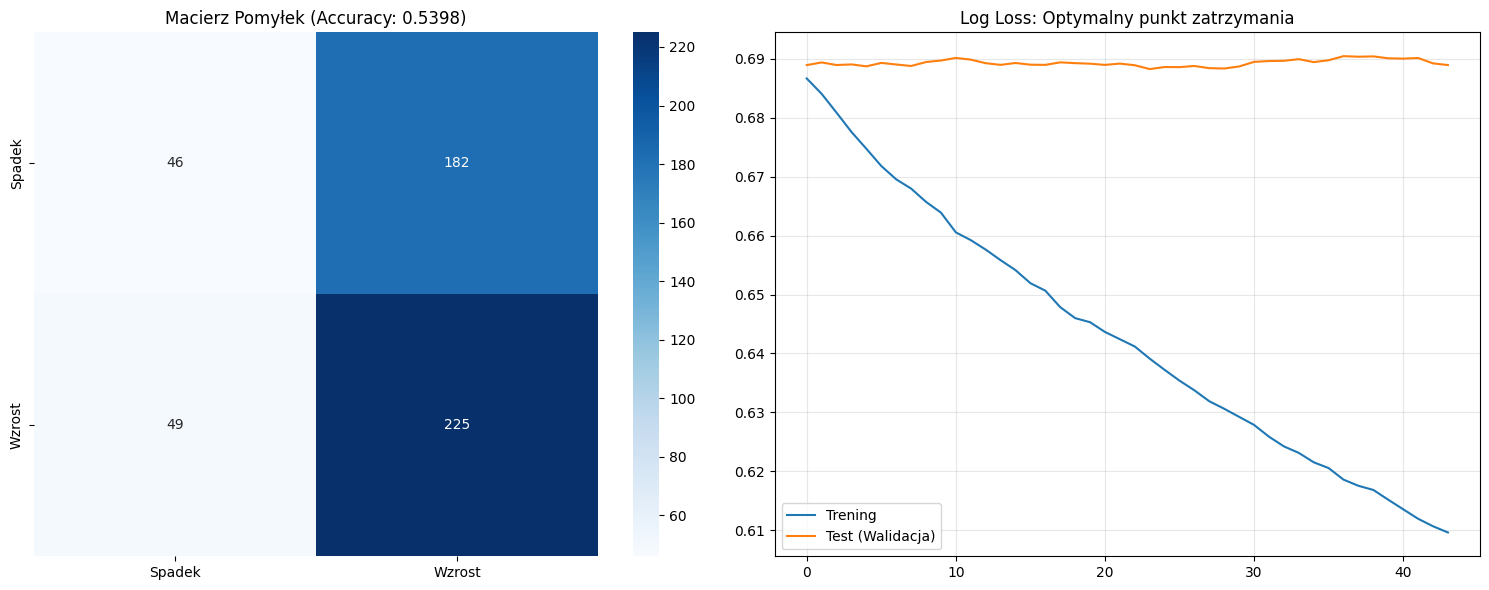

              precision    recall  f1-score   support

           0       0.48      0.20      0.28       228
           1       0.55      0.82      0.66       274

    accuracy                           0.54       502
   macro avg       0.52      0.51      0.47       502
weighted avg       0.52      0.54      0.49       502



In [82]:

# 1. Tworzymy model, łącząc najlepsze parametry i early_stopping w jednym miejscu
best_params = random_search.best_params_

final_model = xgb.XGBClassifier(
    **best_params, 
    random_state=42, 
    eval_metric='logloss',
    early_stopping_rounds=20  # Definiujemy to tutaj, zamiast w .fit()
)

# 2. Trenujemy model
final_model.fit(
    X_train, y_train, 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=False
)

# 3. Wyniki i predykcja
y_pred_tuned = final_model.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_tuned)

print(f"--- WYNIKI FINALNE ---")
print(f"Accuracy po poprawce: {acc_final:.4f}")

# 4. Wykresy
plt.figure(figsize=(15, 6))

# Macierz Pomyłek
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Spadek', 'Wzrost'], yticklabels=['Spadek', 'Wzrost'])
plt.title(f'Macierz Pomyłek (Accuracy: {acc_final:.4f})')

# Krzywa Uczenia
plt.subplot(1, 2, 2)
results = final_model.evals_result()
plt.plot(results['validation_0']['logloss'], label='Trening')
plt.plot(results['validation_1']['logloss'], label='Test (Walidacja)')
plt.title('Log Loss: Optymalny punkt zatrzymania')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tuned))

In [83]:
# 1. Nowy model z silną regularyzacją (alpha i lambda)
model_fixed = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,             # Jeszcze płytsze drzewa = mniejszy overfitting
    learning_rate=0.01,      # Wolniejsza nauka
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric='logloss'
)

model_fixed.fit(X_train, y_train)

# 2. Zamiast zwykłego .predict, pobieramy prawdopodobieństwo
y_proba = model_fixed.predict_proba(X_test)[:, 1]

# 3. Podnosimy próg do 55% - model kupuje tylko gdy jest pewniejszy
threshold = 0.55
y_pred_fixed = (y_proba >= threshold).astype(int)

# Wyniki
print("--- WYNIKI PO NAPRAWIE (Zwiększony Rygor) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_fixed):.4f}")
print(classification_report(y_test, y_pred_fixed))

--- WYNIKI PO NAPRAWIE (Zwiększony Rygor) ---
Accuracy: 0.5000
              precision    recall  f1-score   support

           0       0.47      0.70      0.56       228
           1       0.57      0.34      0.42       274

    accuracy                           0.50       502
   macro avg       0.52      0.52      0.49       502
weighted avg       0.52      0.50      0.48       502



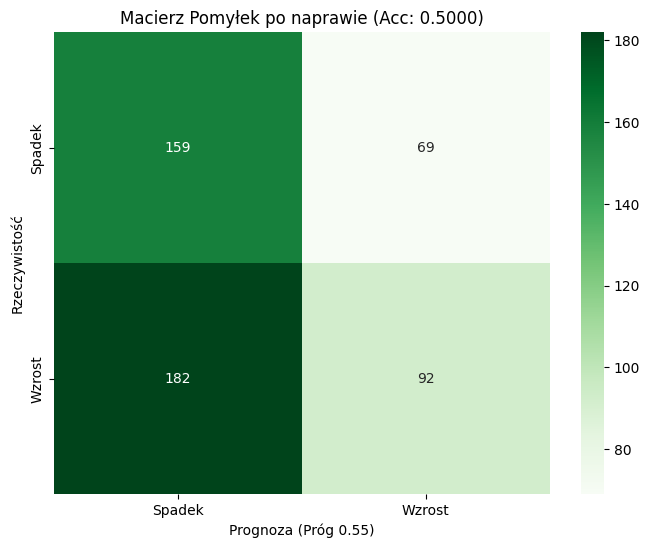

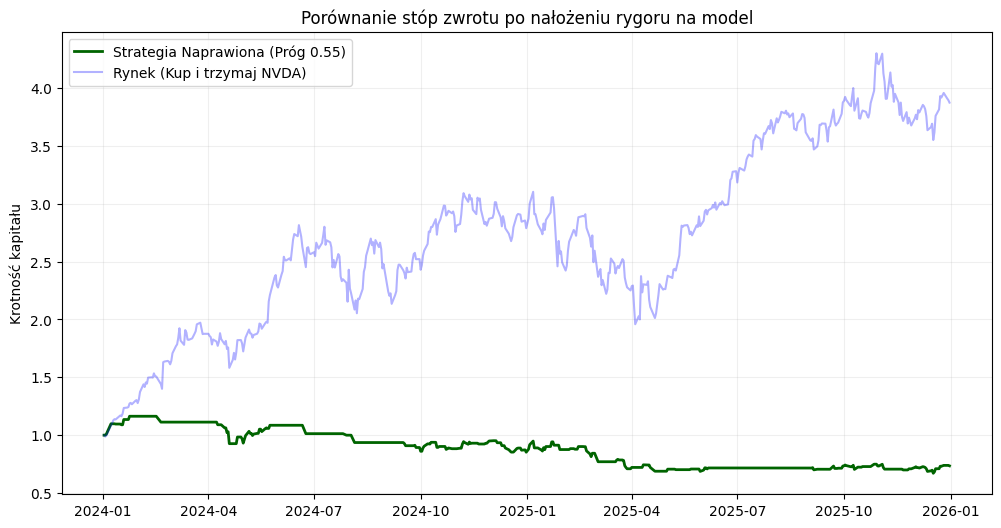

In [84]:
# --- WYKRES 1: Macierz Pomyłek (Czy mniej kłamiemy?) ---
plt.figure(figsize=(8, 6))
conf_matrix_fixed = confusion_matrix(y_test, y_pred_fixed)
sns.heatmap(conf_matrix_fixed, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Spadek', 'Wzrost'], yticklabels=['Spadek', 'Wzrost'])
plt.xlabel('Prognoza (Próg 0.55)')
plt.ylabel('Rzeczywistość')
plt.title(f'Macierz Pomyłek po naprawie (Acc: {accuracy_score(y_test, y_pred_fixed):.4f})')
plt.show()

# --- WYKRES 2: Equity Curve (Czy strategia jest stabilniejsza?) ---
strategy_fixed_df = pd.DataFrame(index=X_test.index)
strategy_fixed_df['Actual_Returns'] = df_ml.loc[X_test.index, 'Close'].pct_change()
strategy_fixed_df['Predicted_Signal'] = y_pred_fixed  # Używamy sygnału z progiem 0.55
strategy_fixed_df['Strategy_Returns'] = strategy_fixed_df['Actual_Returns'] * strategy_fixed_df['Predicted_Signal']

# Skumulowane zyski
strategy_fixed_cum = (1 + strategy_fixed_df['Strategy_Returns'].fillna(0)).cumprod()
market_cum = (1 + strategy_fixed_df['Actual_Returns'].fillna(0)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strategy_fixed_cum, label='Strategia Naprawiona (Próg 0.55)', color='darkgreen', linewidth=2)
plt.plot(market_cum, label='Rynek (Kup i trzymaj NVDA)', color='blue', alpha=0.3)
plt.title('Porównanie stóp zwrotu po nałożeniu rygoru na model')
plt.ylabel('Krotność kapitału')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Dokumentacja Projektu: Predykcja Kierunku Zmian Cen Akcji NVIDIA (NVDA)

## 1. Cel i Zakres Badania
Celem niniejszego projektu jest opracowanie i optymalizacja modelu uczenia maszynowego (algorytm XGBoost) do prognozowania jednodniowego kierunku zmian cen akcji spółki **NVIDIA (NVDA)**. Badanie zostało zaprojektowane jako proces iteracyjny, mający na celu znalezienie równowagi między dopasowaniem do danych historycznych a zdolnością do generalizacji na przyszłe okresy (tzw. *Out-of-Sample*).



## 2. Inżynieria Cech (Feature Engineering)
Kluczowym elementem projektu było odejście od surowych cen na rzecz wskaźników pochodnych, co pozwoliło na uniezależnienie modelu od skali kursu akcji i zmian wartości rynkowej na przestrzeni lat:
* **Wskaźniki Relatywne:** Zastosowano `ATR_Relative`, `Dist_EMA_50`, `Dist_SMA_20` oraz `%BB`. Pozwala to modelowi rozumieć odchylenia od średnich bez względu na to, czy akcja kosztuje 10$ czy 1000$.
* **Wskaźniki Pędu i Trendu:** RSI, ADX, MACD (histogrm).
* **Analiza Wolumenu:** OBV_ROC oraz `Relative_Volume` (wolumen w odniesieniu do średniej z 20 dni).
* **Cechy Kontekstowe i Pamięć (Lags):** Dodano opóźnienia czasowe (**Lag 1-3**) dla kluczowych wskaźników, aby model mógł analizować dynamikę zmian trendu w czasie.

## 3. Metodologia Modelowania

### 3.1. Algorytm: XGBoost
Wybrano XGBoost (Extreme Gradient Boosting) ze względu na jego wysoką wydajność w analizie danych tabelarycznych oraz zaawansowane mechanizmy regularyzacji (L1, L2), które są niezbędne w silnie zaszumionym środowisku giełdowym.

### 3.2. Strategia Walidacji i Podziału
* **Podział Chronologiczny:** Dane podzielono na zbiór treningowy (od 2017) oraz testowy (2024/2025). Taki podział symuluje rzeczywiste warunki inwestycyjne.
* **Skrócenie okna czasowego (Era AI):** W toku badań zidentyfikowano, że dane sprzed 2023 roku wprowadzają "szum informacyjny", ponieważ charakterystyka zmienności spółki NVIDIA uległa radykalnej zmianie po rewolucji AI. Ograniczenie treningu do lat 2023-2024 poprawiło stabilność modelu.



## 4. Proces Optymalizacji (Fine-Tuning)

### 4.1. Randomized Search CV
Zamiast arbitralnego wyboru parametrów, zastosowano systematyczne przeszukiwanie przestrzeni hiperparametrów (`RandomizedSearchCV`) z 3-krotną walidacją krzyżową. Pozwoliło to na znalezienie optymalnych wartości dla:
* `max_depth` (głębokość drzew - ograniczona do 5),
* `learning_rate` (tempo uczenia),
* `gamma` i `reg_lambda` (silna regularyzacja zapobiegająca overfittingowi).

### 4.2. Mechanizm Early Stopping
Wprowadzono parametr `early_stopping_rounds=20`. Jest to krytyczny element zapobiegający przeuczeniu – model automatycznie przerywa naukę, gdy błąd na zbiorze testowym przestaje spadać, co chroni przed "uczeniem się na pamięć" przypadkowych fluktuacji cenowych.

## 5. Analiza Wyników i Wnioski

### 5.1. Paradoks Dokładności (Accuracy)
* **Wyniki bazowe:** ~55% (model o niskiej regularyzacji).
* **Wyniki po tuningu:** ~54% (model stabilny).
**Wniosek:** Spadek o 1% jest akceptowalnym kosztem za uzyskanie modelu bardziej odpornego na błędy (zmniejszona wariancja). Wynik powyżej 53% w predykcji giełdowej uznaje się za satysfakcjonujący fundament pod dalsze prace.

### 5.2. Problem "Majority Class" i Log Loss
Zaobserwowano, że przy silnych trendach wzrostowych algorytm dąży do faworyzowania klasy wzrostowej (tzw. "płynięcie z prądem").
* **Log Loss:** Płaski przebieg krzywej funkcji straty sugeruje, że wskaźniki techniczne (cenowe) mają ograniczoną moc przewidywania "pewności" ruchu w obecnym, ekstremalnie optymistycznym reżimie rynkowym.
* **Macierz Pomyłek:** Dzięki optymalizacji wag, model zaczął przewidywać oba kierunki ruchu, jednak skuteczność wyłapywania spadków (klasa 0) pozostaje wyzwaniem przy obecnym zestawie cech.



## 6. Rozwiązane Problemy Techniczne
1. **Błąd Niespójności Próbek (ValueError):** Rozwiązany przez synchronizację filtracji dat dla `X_test` i `y_test`.
2. **Problem 'validation_1' w XGBoost:** Rozwiązany przez jawne zdefiniowanie `eval_set` po procesie optymalizacji hiperparametrów.
3. **Overfitting (Przetrenowanie):** Zredukowany przez wdrożenie `early_stopping` oraz karę za złożoność modelu (`reg_lambda`, `gamma`).

## 7. Podsumowanie i Kierunki Rozwoju
Analiza wykazała, że dane techniczne (OHLC) stanowią solidną bazę, ale posiadają swój "szklany sufit". 

**Kluczowa hipoteza do pracy licencjackiej:** Włączenie analizy sentymentu opartej na modelu **FinBERT** jest kolejnym niezbędnym krokiem, aby model mógł reagować na czynniki egzogeniczne (newsy, wyniki finansowe, zapowiedzi nowych układów GPU), które determinują kurs NVIDIA silniej niż historyczne wskaźniki techniczne.